In [2]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

Full: α=3.0684, θ=0.3259, media=1.0000, KS=0.0075, p=0.0000
Erdős-Rényi: α=3.0699, θ=0.3257, media=1.0000, KS=0.0076, p=0.0000
Barabási-Albert: α=3.0715, θ=0.3256, media=1.0000, KS=0.0072, p=0.0000
Watts-Strogatz: α=3.0670, θ=0.3261, media=1.0000, KS=0.0075, p=0.0000


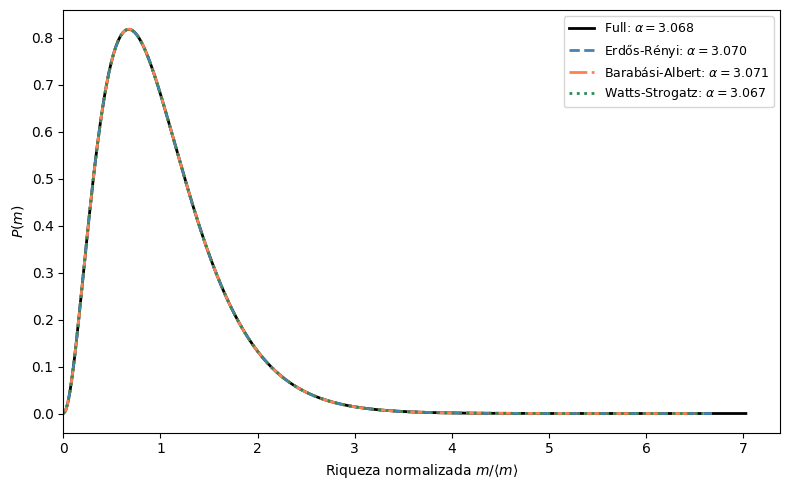

In [9]:
from scipy.stats import gamma, kstest
import numpy as np
import matplotlib.pyplot as plt

M = 5e4
N = 500

datasets = {
    'Full':             np.load('Full/Pm_lamb0.4.npy') / (M/N),
    'Erdős-Rényi':      np.load('Erdos-Renyi/Pm_lamb0.4.npy') / (M/N),
    'Barabási-Albert':  np.load('Barabasi-Albert/Pm_lamb0.4.npy') / (M/N),
    'Watts-Strogatz':   np.load('Watts-Strogatz/Pm_lamb0.4.npy') / (M/N),
}

colors     = ['black', 'steelblue', 'coral', 'seagreen']
linestyles = ['-', '--', '-.', ':']

fig, ax = plt.subplots(figsize=(8, 5))

for (label, data), color, ls in zip(datasets.items(), colors, linestyles):
    data_flat = data.flatten()
    alpha, loc, scale = gamma.fit(data_flat, floc=0)

    x_fit = np.linspace(0, data.max(), 300)
    y_fit = gamma.pdf(x_fit, a=alpha, loc=0, scale=scale)

    ax.plot(x_fit, y_fit, color=color, lw=2, linestyle=ls,
            label=fr'{label}: $\alpha={alpha:.3f}$')

    stat, p = kstest(data_flat, 'gamma', args=(alpha, 0, scale))
    print(f"{label}: α={alpha:.4f}, θ={scale:.4f}, media={alpha*scale:.4f}, KS={stat:.4f}, p={p:.4f}")

ax.set_xlim(left=0)
ax.set_xlabel('Riqueza normalizada $m/\\langle m \\rangle$')
ax.set_ylabel('$P(m)$')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()